<div class="alert alert-block alert-success">
<b>Comentario general del revisor</b> <a class="tocSkip"></a><br />
Status del proyecto: <b>Aprobado</b>
</div>


¡Hola!<br />
Soy **Francisco Cortés**, estoy contento de revisar tu proyecto y ser parte de tu proceso de aprendizaje.
A lo largo del texto, haré algunas observaciones sobre mejoras en el código y también haré comentarios sobre tus percepciones sobre el tema. Si existe algún error en el código, no te preocupes, estoy aquí para ayudarte a mejorarlo, en la primera iteración te lo señalaré para que tengas la oportunidad de corregirlo, pero si aún no encuentras una solución para esta tarea, te daré una pista más precisa en la próxima iteración y también algunos ejemplos prácticos. Estaré abierto a retroalimentación y discusiones sobre el tema.<br />
Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o borres**.
Revisaré cuidadosamente tu código para comprobar que se han cumplido con los requisitos y te proporcionaré mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si la ejecución fue perfecta succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existe alguna recomendación para que tu código mejore.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existen correcciones necesarias para cumplir con los requisitos. El trabajo no puede ser aceptado si hay alguna caja roja.
</div>

Puedes responderme de la siguiente manera:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
</div>

# Proyecto Integrado 1: Análisis de Ventas de Videojuegos

## Tienda online Ice, que vende videojuegos en todo el mundo.

Objetivo: Identificar patrones que determinen si un juego será un éxito comercial para detectar proyectos prometedores y planificar campañas publicitarias para 2017.

### Paso 1: Configuración inicial y carga de datos

In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

In [2]:
# Carga el dataset
df = pd.read_csv('/datasets/games.csv')

#### Exploración inicial de datos

In [3]:
# Estudiar información general
df.info()
display(df.head())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.000000,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000
mean,2006.484616,0.263377,0.145060,0.077617,0.047342,68.967679
std,5.877050,0.813604,0.503339,0.308853,0.186731,13.938165
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000


#### Observaciones iniciales:

- Nombres de columnas en diferentes tipos de formato
- Valores ausentes en Year_of_Release, Critic_Score, User_Score, Rating
- User_Score es tipo object (posiblemente contiene 'tbd')
- Year_of_Release debería ser entero pero es float por los NaN

### Paso 2: Preparación y limpieza de datos

#### Estandarización de nombres de columnas

In [4]:
# Poner nombres de columnas en minúsculas
df.columns = df.columns.str.lower()
print(df.columns)

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


#### Tratamiento de valores ausentes y conversión de tipos

- Los valores tbd en user_score se convierten a NaN, indicando que la calificación está pendiente.
- Las reseñas ausentes pueden deberse a que algunos juegos no fueron evaluados por críticos o usuarios.

In [5]:
# Análisis de valores ausentes
print("Valores ausentes por columna:")
print(df.isnull().sum())


Valores ausentes por columna:
name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64


In [6]:
# Tratamiento de user_score

print("Valores únicos en user_score:", df['user_score'].unique()[:10])

df['user_score'] = df['user_score'].replace('tbd', np.nan)
df['user_score'] = df['user_score'].astype('float')


Valores únicos en user_score: ['8' nan '8.3' '8.5' '6.6' '8.4' '8.6' '7.7' '6.3' '7.4']


In [7]:
# Tratamiento de year_of_release
print(f"Valores ausentes en year_of_release: {df['year_of_release'].isna().sum()}")

df = df.dropna(subset=['year_of_release'])
df['year_of_release'] = df['year_of_release'].astype('int')

Valores ausentes en year_of_release: 269


In [8]:
# Tratamiento de rating
df['rating'] = df['rating'].fillna('unknown')
print("Valores ausentes en 'rating' rellenados con 'unknown'")

Valores ausentes en 'rating' rellenados con 'unknown'


In [9]:
# Verificación de tipos de datos
df.info()
display(df.head())
df.describe()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16446 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16446 non-null  object 
 2   year_of_release  16446 non-null  int64  
 3   genre            16444 non-null  object 
 4   na_sales         16446 non-null  float64
 5   eu_sales         16446 non-null  float64
 6   jp_sales         16446 non-null  float64
 7   other_sales      16446 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float64
 10  rating           16446 non-null  object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.5+ MB


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,unknown
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,unknown


,year_of_release,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score
count,16446.000000,16446.000000,16446.000000,16446.000000,16446.000000,7983.000000,7463.000000
mean,2006.484616,0.264089,0.145945,0.078479,0.047593,68.994363,7.126330
std,5.877050,0.818416,0.506696,0.311082,0.187994,13.920060,1.499447
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000,0.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000,6.400000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000,7.500000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000,8.200000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000,9.700000


#### Creación de columna de ventas totales

In [10]:
# Calcular ventas totales
df['total_sales'] = df[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)
print("Columna total_sales creada")

df[['name', 'platform', 'year_of_release', 'total_sales']].head()

Columna total_sales creada


,name,platform,year_of_release,total_sales
0,Wii Sports,Wii,2006,82.54
1,Super Mario Bros.,NES,1985,40.24
2,Mario Kart Wii,Wii,2008,35.52
3,Wii Sports Resort,Wii,2009,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,31.38


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>

Hiciste un buen trabajo al cambiar los nombres de las columnas, sus tipos de datos y reemplazar los valores ausentes
</div>


### Paso 3: Análisis de datos

#### Evolución de lanzamientos por año

- Analizamos la evolución temporal de lanzamientos para identificar períodos con datos significativos.

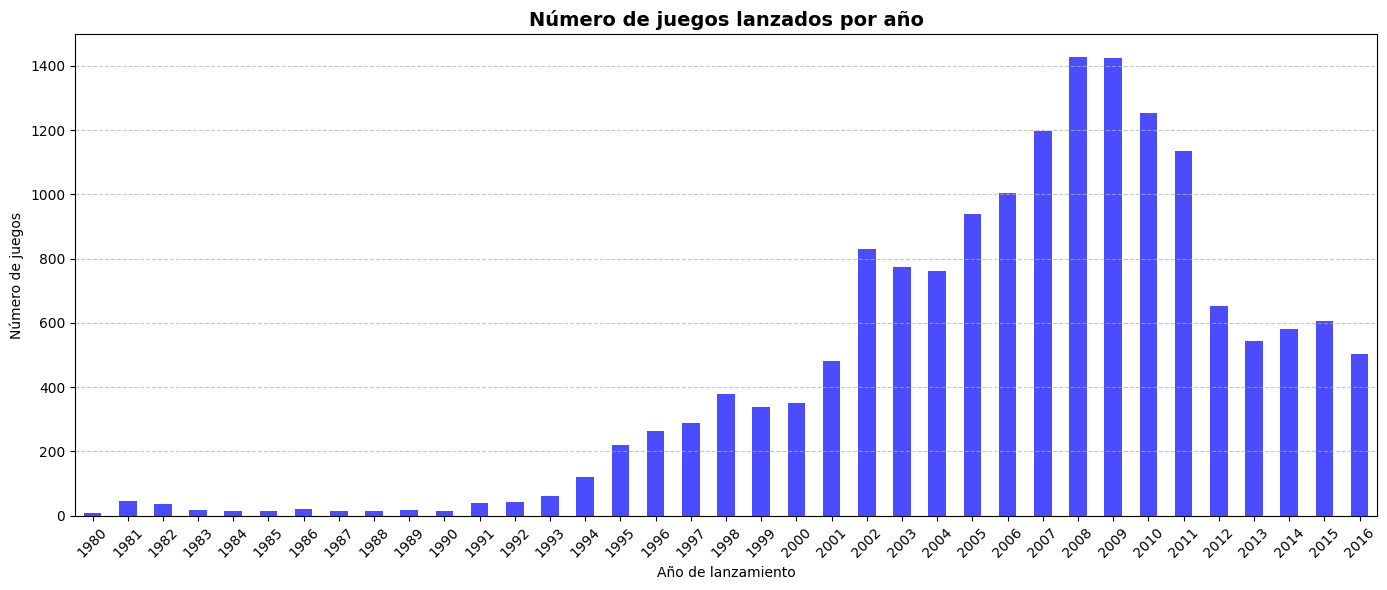

Año con más lanzamientos: 2008 con 1427 juegos


In [11]:
# Juegos lanzados por año
games_per_year = df.groupby('year_of_release')['name'].count()

plt.figure(figsize=(14, 6))
games_per_year.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Número de juegos lanzados por año', fontsize=14, fontweight='bold')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Número de juegos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Año con más lanzamientos:", games_per_year.idxmax(), "con", games_per_year.max(), "juegos")

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!<br/>

Buena manera de presentar los datos, podemos ver claramente la tendencia de los videojuegos con un incremento constante en años anteriores que ha empezado a ir en declive en los últimos años
</div>


#### Análisis de plataformas

- Identificamos las plataformas con mayores ventas totales y su distribución.

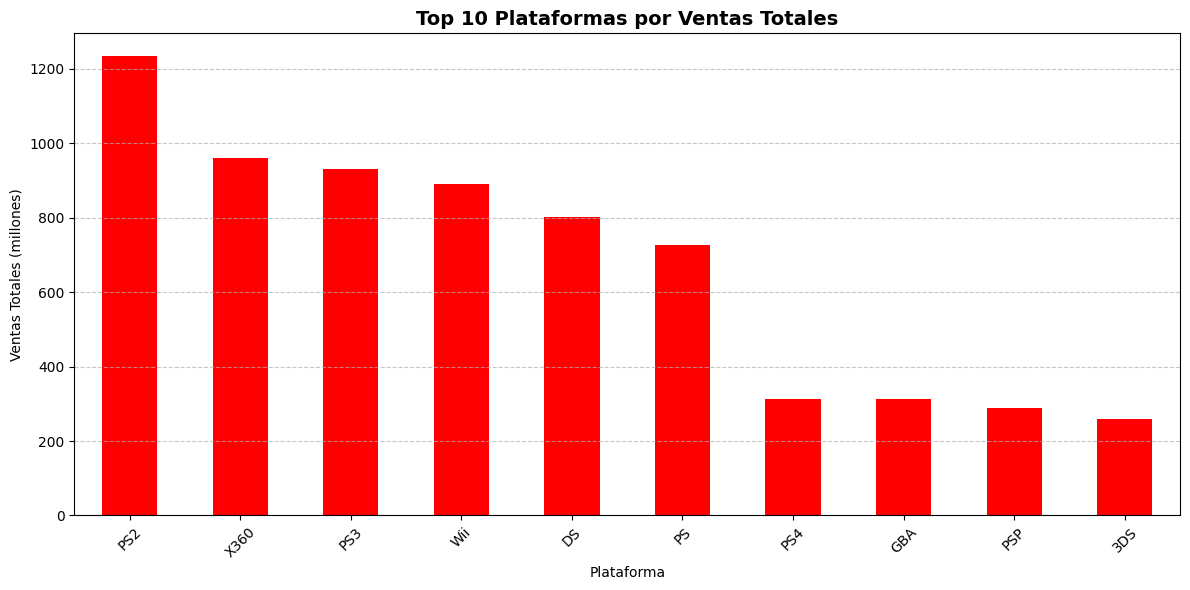

Top 5 plataformas por ventas:
platform
PS2     1233.56
X360     961.24
PS3      931.34
Wii      891.18
DS       802.78
Name: total_sales, dtype: float64


In [12]:
# Ventas totales por plataforma
platform_sales = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
platform_sales.head(10).plot(kind='bar', color='Red')
plt.title('Top 10 Plataformas por Ventas Totales', fontsize=14, fontweight='bold')
plt.xlabel('Plataforma')
plt.ylabel('Ventas Totales (millones)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Top 5 plataformas por ventas:")
print(platform_sales.head())

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho! podemos ver gracias a la gráfica que los primeros lugares tienen una diferencia significativa respecto a los últimos lugares
</div>


#### Determinación del período relevante (2013-2016)

Evolución de plataformas

- Estudiamos el ciclo de vida de las plataformas para determinar cuáles están en crecimiento, estabilidad o declive.

In [13]:
# Filtrar datos relevantes para análisis futuro
df_relevant = df[df['year_of_release'] >= 2013].copy()
print(f"Período relevante (2013-2016): {df_relevant.shape[0]} juegos")

Período relevante (2013-2016): 2233 juegos


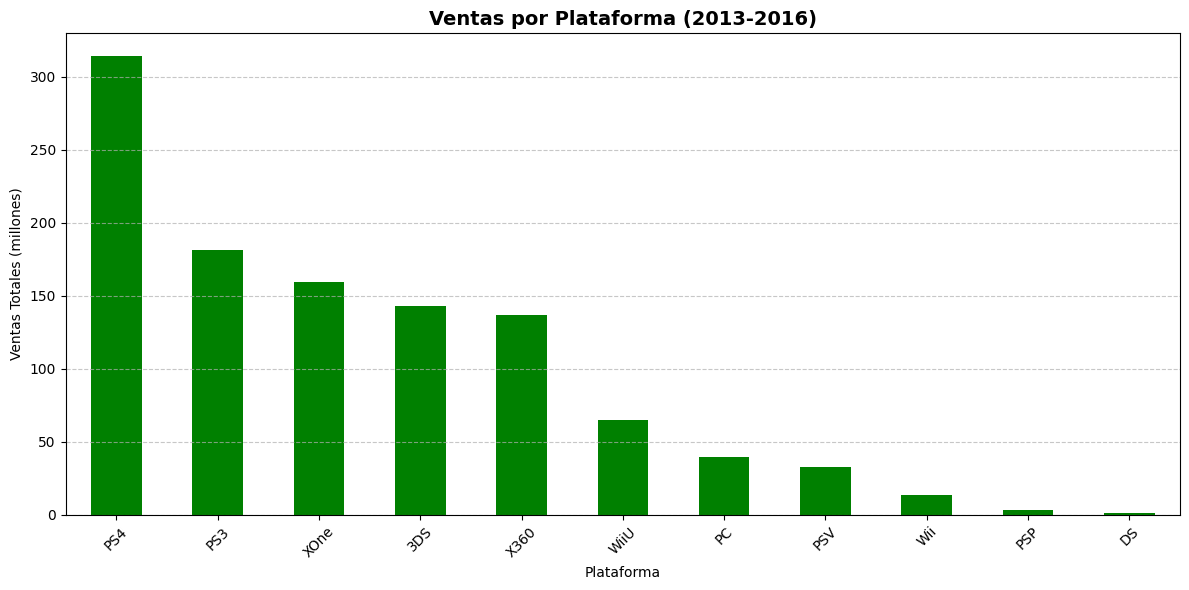

In [14]:
# Ventas por plataforma en período relevante
platform_sales_recent = df_relevant.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
platform_sales_recent.plot(kind='bar', color='green')
plt.title('Ventas por Plataforma (2013-2016)', fontsize=14, fontweight='bold')
plt.xlabel('Plataforma')
plt.ylabel('Ventas Totales (millones)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Distribución de ventas por plataforma

- El diagrama nos permite comparar las distribuciones de ventas entre diferentes plataformas.

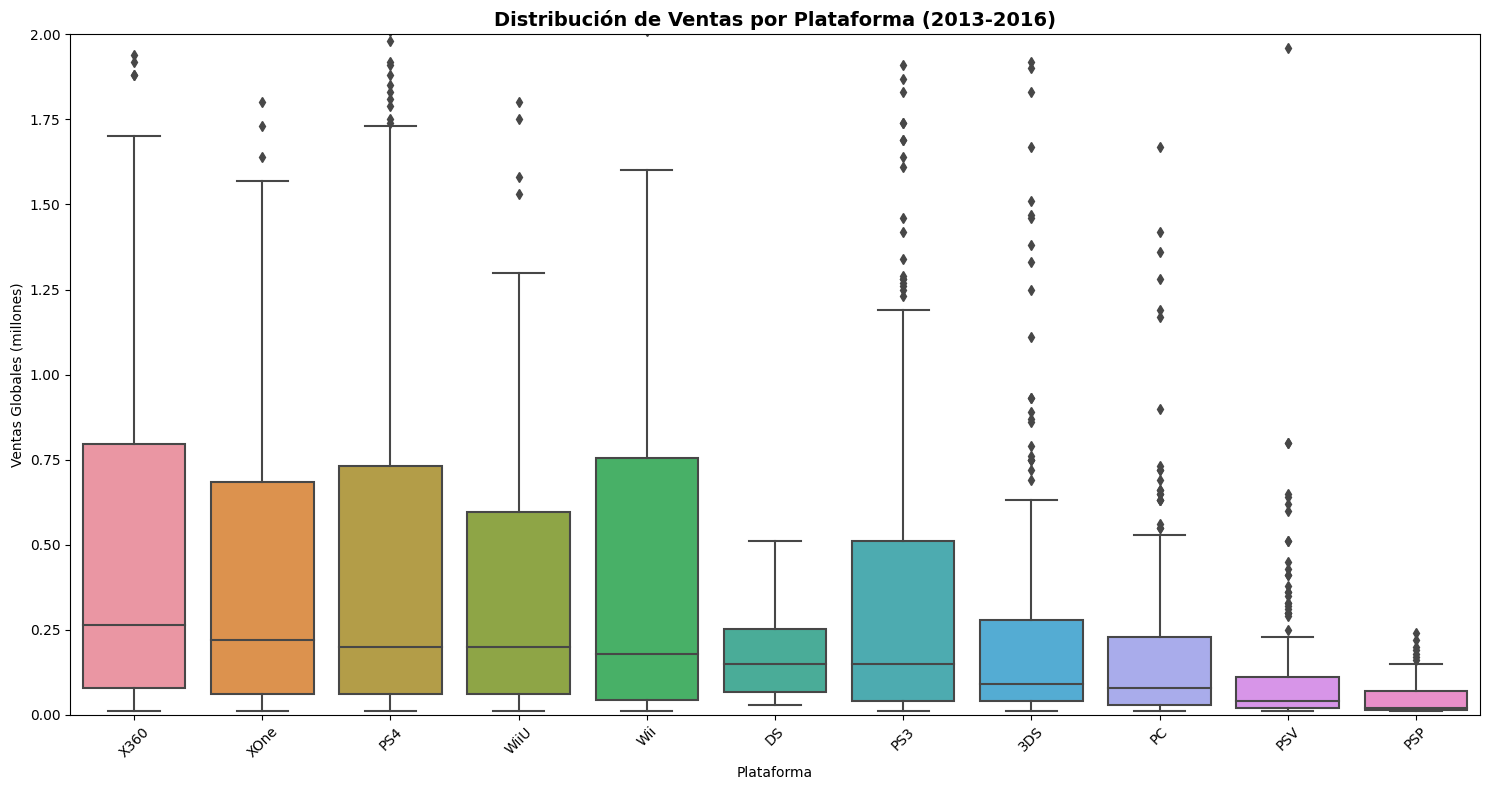

In [15]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_relevant, x='platform', y='total_sales', 
            order=df_relevant.groupby('platform')['total_sales'].median().sort_values(ascending=False).index)
plt.title('Distribución de Ventas por Plataforma (2013-2016)', fontsize=14, fontweight='bold')
plt.xlabel('Plataforma')
plt.ylabel('Ventas Globales (millones)')
plt.ylim(0, 2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!

El diagrama de caja nos muestra como en algunas plataformas las ventas estan consolidadas mientras que en otras consolas las ventas son muy disparejas lo que incrementa el rango intercuartil
</div>


#### Influencia de las reseñas en las ventas

- Investigamos la relación entre las calificaciones de críticos/usuarios y el éxito comercial.

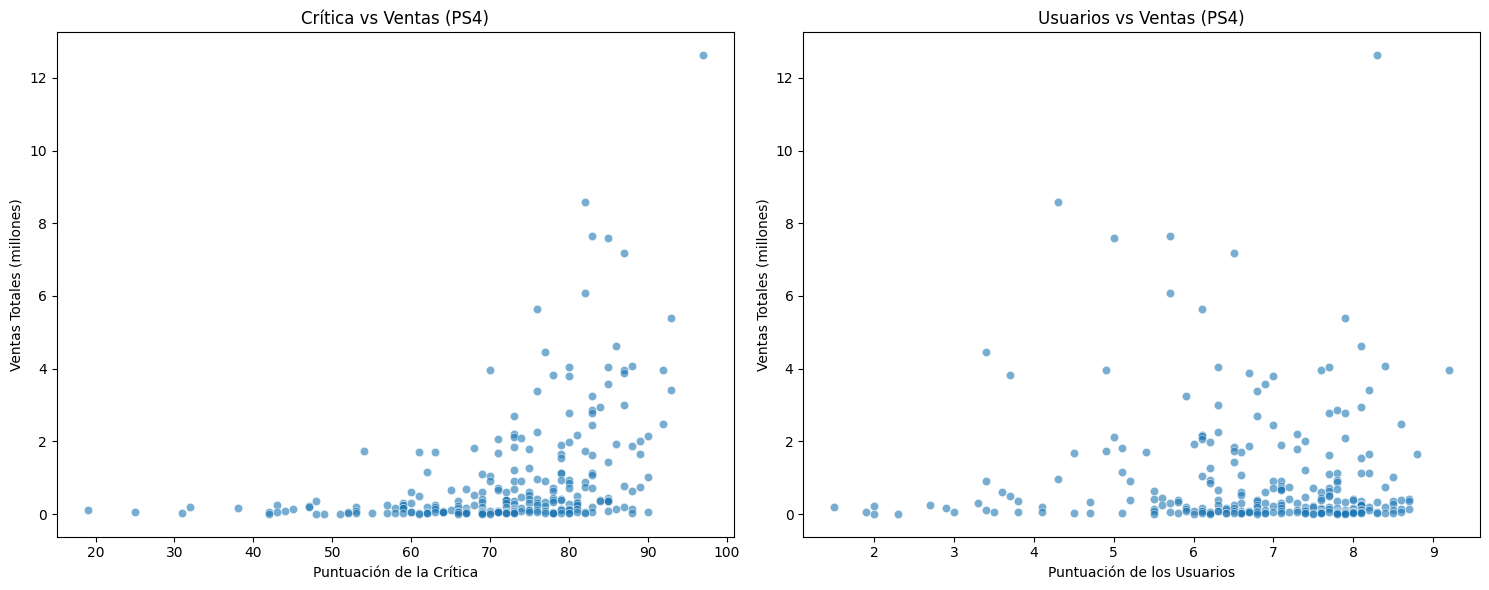

In [16]:
# Análisis para PS4
ps4_data = df_relevant[df_relevant['platform'] == 'PS4']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Crítica vs Ventas
sns.scatterplot(data=ps4_data, x='critic_score', y='total_sales', ax=axes[0], alpha=0.6)
axes[0].set_title('Crítica vs Ventas (PS4)')
axes[0].set_xlabel('Puntuación de la Crítica')
axes[0].set_ylabel('Ventas Totales (millones)')

# Usuarios vs Ventas
sns.scatterplot(data=ps4_data, x='user_score', y='total_sales', ax=axes[1], alpha=0.6)
axes[1].set_title('Usuarios vs Ventas (PS4)')
axes[1].set_xlabel('Puntuación de los Usuarios')
axes[1].set_ylabel('Ventas Totales (millones)')

plt.tight_layout()
plt.show()

In [17]:
# Cálculo de correlaciones
correlation_ps4 = ps4_data[['critic_score', 'user_score', 'total_sales']].corr()
print("Correlación entre reseñas y ventas para PS4:")
print(correlation_ps4)

Correlación entre reseñas y ventas para PS4:
              critic_score  user_score  total_sales
critic_score      1.000000    0.557654     0.406568
user_score        0.557654    1.000000    -0.031957
total_sales       0.406568   -0.031957     1.000000


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!

Buena manera de mostrar la correlación entre las ventas y las reseñas, no siempre las buenas reseñas van a implicar un gran numero de ventas
</div>


#### Análisis por géneros

- Identificamos qué tipos de juegos generan mayores ventas a nivel global.

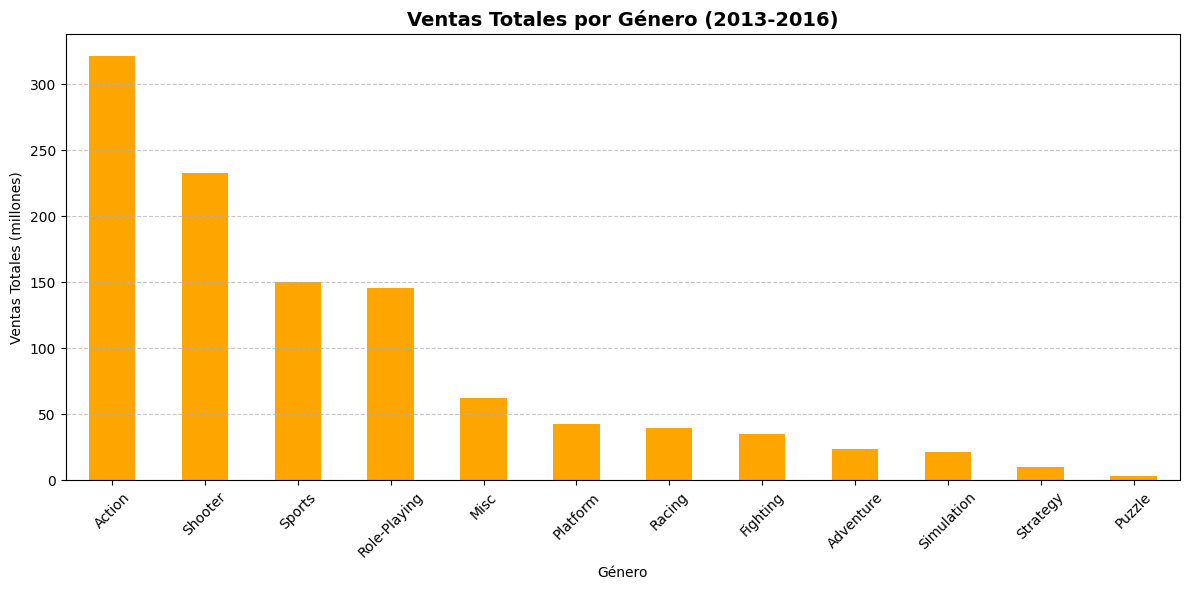

In [18]:
# Ventas por género
genre_sales = df_relevant.groupby('genre')['total_sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
genre_sales.plot(kind='bar', color='orange')
plt.title('Ventas Totales por Género (2013-2016)', fontsize=14, fontweight='bold')
plt.xlabel('Género')
plt.ylabel('Ventas Totales (millones)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

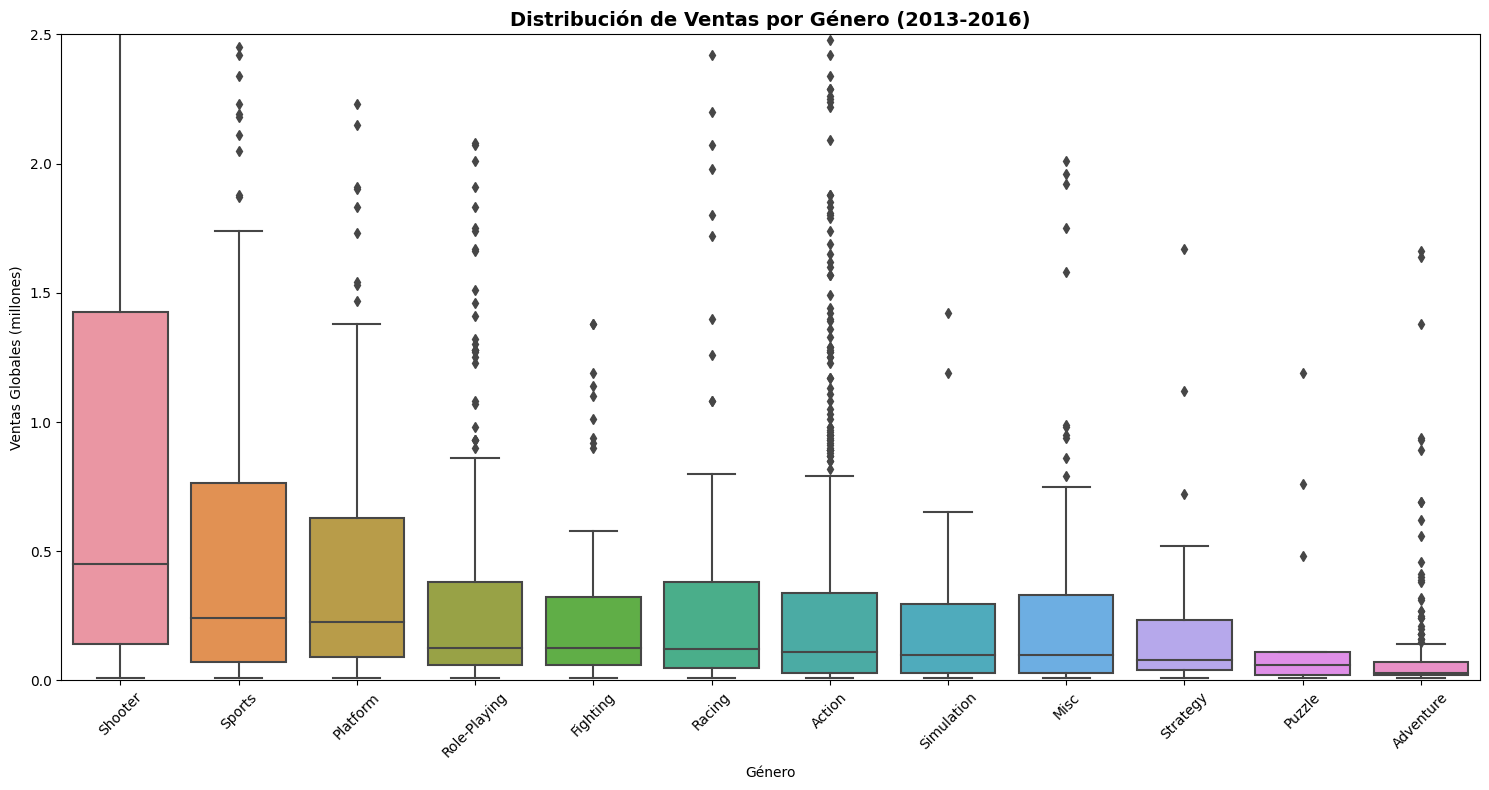

In [19]:
# Distribución de ventas por género
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_relevant, x='genre', y='total_sales', 
            order=df_relevant.groupby('genre')['total_sales'].median().sort_values(ascending=False).index)
plt.title('Distribución de Ventas por Género (2013-2016)', fontsize=14, fontweight='bold')
plt.xlabel('Género')
plt.ylabel('Ventas Globales (millones)')
plt.ylim(0, 2.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!

Buena manera de presentar los datos, podemos ver claramente cuales son los géneros preferidos de las personas, las observaciones que haces me parecen buenas también
</div>


### Paso 4: Perfil de usuario para cada región

#### Análisis regional comparativo:

##### Crear perfil de usuario para cada región

Norteamérica (NA):
- Plataformas preferidas
- Géneros más populares
- Influencia del rating ESRB

Europa (EU):
- Preferencias de plataformas
- Géneros dominantes
- Impacto del rating

Japón (JP):
- Plataformas líderes
- Géneros favoritos
- Efecto del rating ESRB

Hallazgos clave: Identificamos diferencias culturales significativas en preferencias entre regiones.

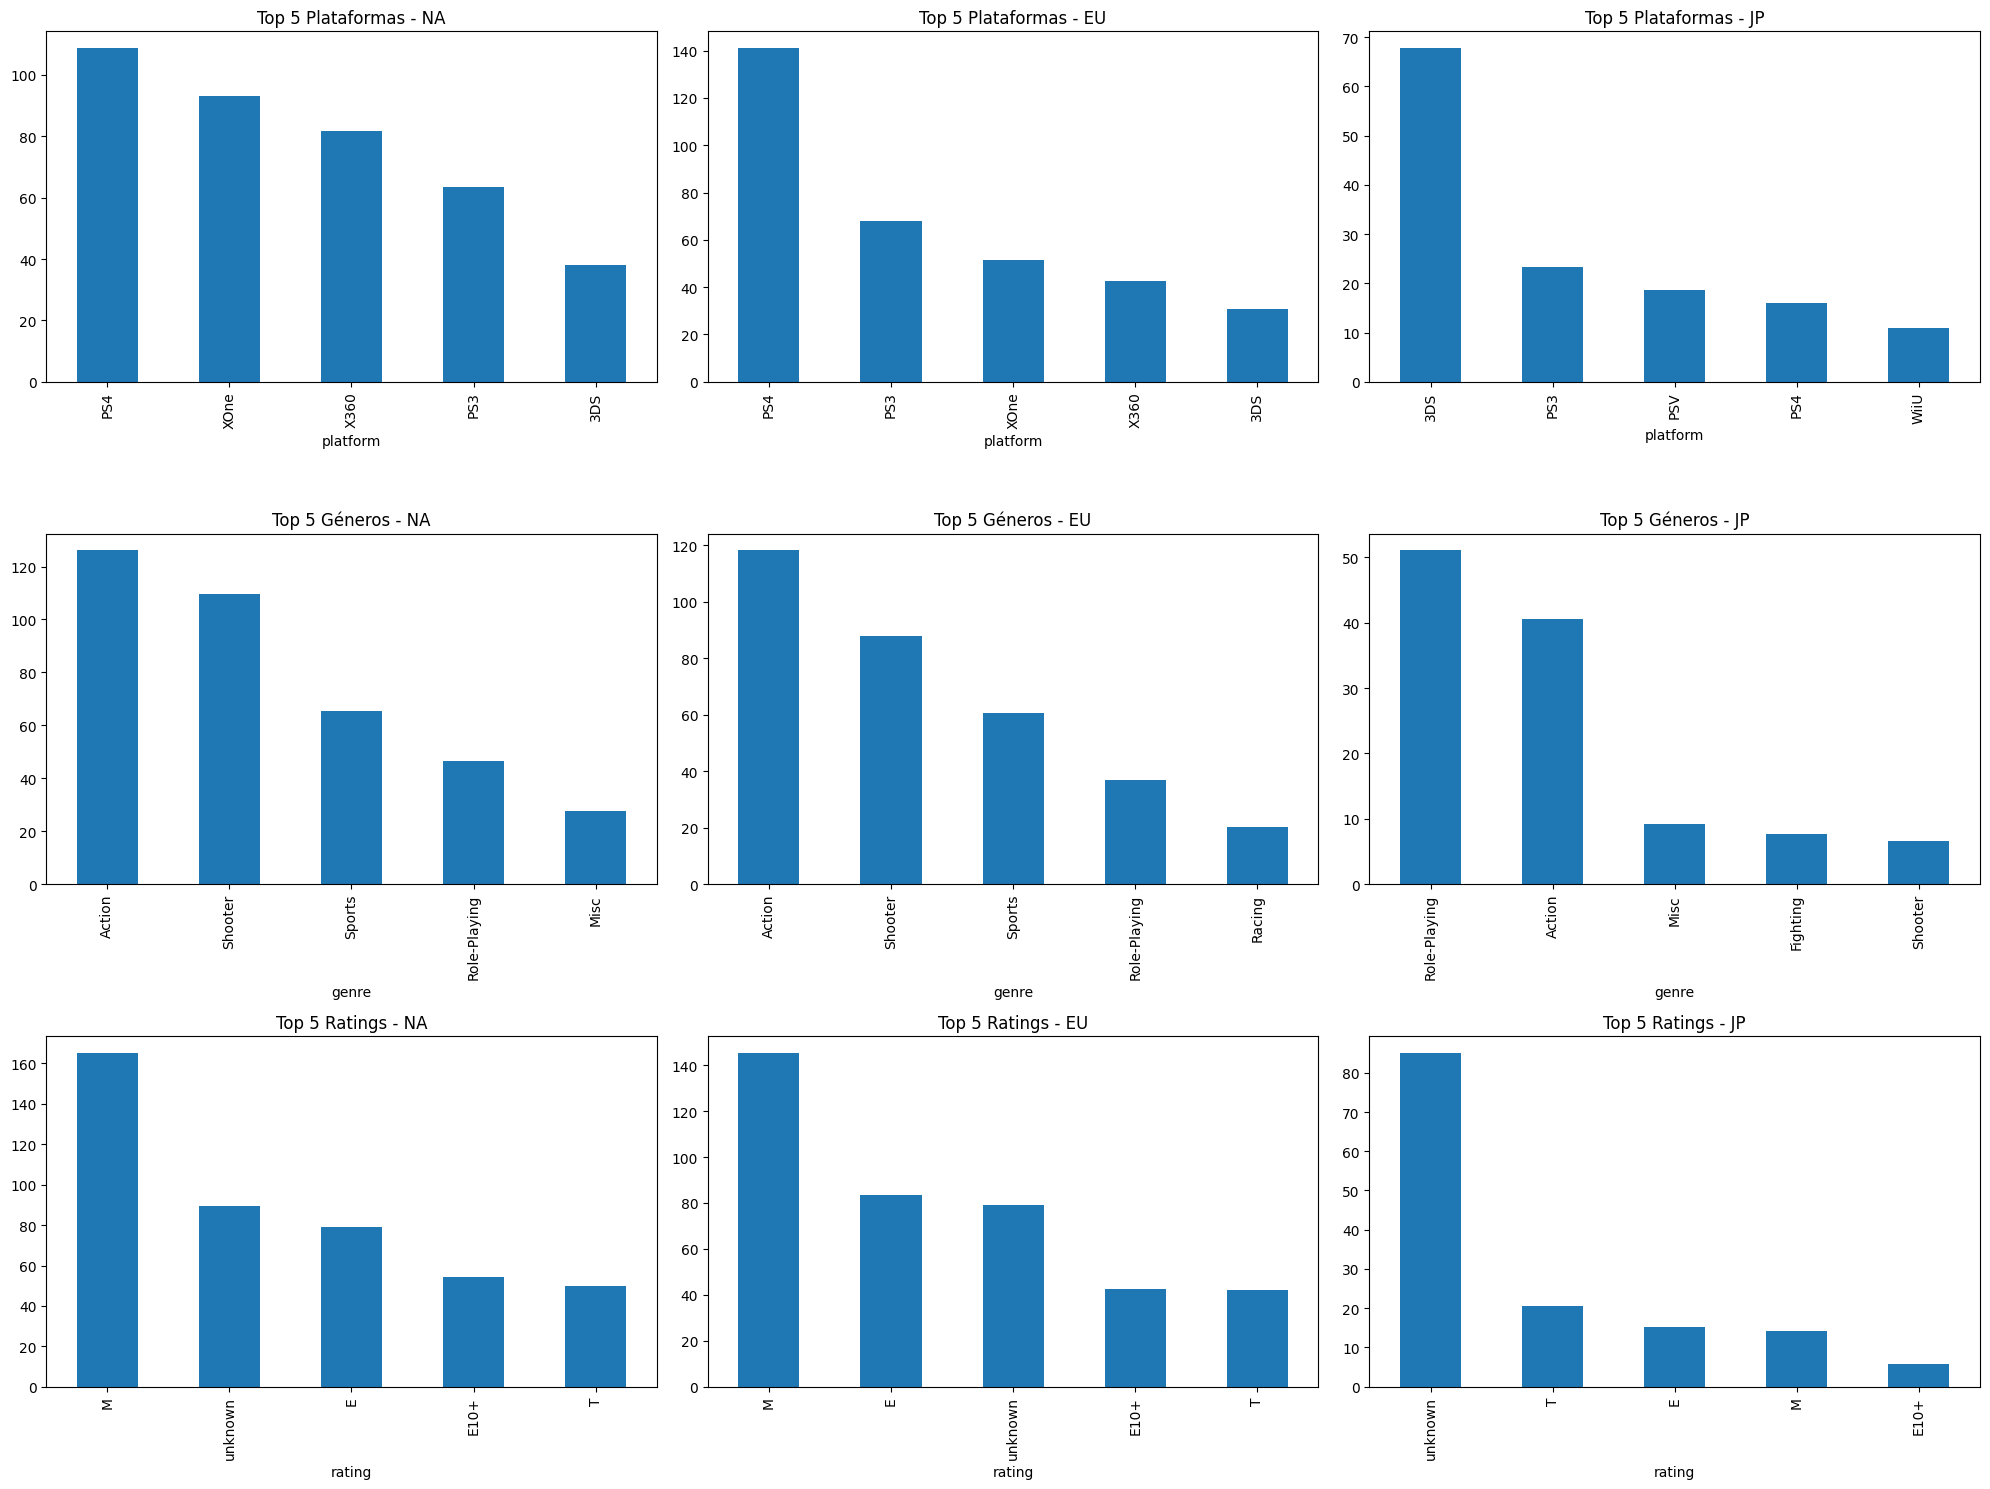

In [20]:
# Función para análisis regional
def get_top5_by_region(df, category, region_sales):
    return df.groupby(category)[region_sales].sum().sort_values(ascending=False).head(5)

# Análisis por región
fig, axes = plt.subplots(3, 3, figsize=(20, 15))

# Plataformas
get_top5_by_region(df_relevant, 'platform', 'na_sales').plot(kind='bar', ax=axes[0,0], title='Top 5 Plataformas - NA')
get_top5_by_region(df_relevant, 'platform', 'eu_sales').plot(kind='bar', ax=axes[0,1], title='Top 5 Plataformas - EU')
get_top5_by_region(df_relevant, 'platform', 'jp_sales').plot(kind='bar', ax=axes[0,2], title='Top 5 Plataformas - JP')

# Géneros
get_top5_by_region(df_relevant, 'genre', 'na_sales').plot(kind='bar', ax=axes[1,0], title='Top 5 Géneros - NA')
get_top5_by_region(df_relevant, 'genre', 'eu_sales').plot(kind='bar', ax=axes[1,1], title='Top 5 Géneros - EU')
get_top5_by_region(df_relevant, 'genre', 'jp_sales').plot(kind='bar', ax=axes[1,2], title='Top 5 Géneros - JP')

# Ratings
get_top5_by_region(df_relevant, 'rating', 'na_sales').plot(kind='bar', ax=axes[2,0], title='Top 5 Ratings - NA')
get_top5_by_region(df_relevant, 'rating', 'eu_sales').plot(kind='bar', ax=axes[2,1], title='Top 5 Ratings - EU')
get_top5_by_region(df_relevant, 'rating', 'jp_sales').plot(kind='bar', ax=axes[2,2], title='Top 5 Ratings - JP')

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Gran manera de mostrar las similitudes/diferencias de cada una de las regiones
</div>


### Paso 5: Pruebas de hipótesis

#### Hipótesis 1: Calificaciones de usuarios para Xbox One vs PC

*Hipótesis nula (H0):*  Las calificaciones promedio de usuarios para Xbox One y PC son iguales
*Hipótesis alternativa (H1):*  Las calificaciones promedio de usuarios para Xbox One y PC son diferentes

*Metodología:*  Prueba t de Student para dos muestras independientes

*Criterio:*  Verificamos igualdad de varianzas con prueba de Levene antes de seleccionar el tipo de prueba t

In [21]:
print("PRUEBA DE HIPÓTESIS 1")
print("H₀: Las calificaciones promedio de usuarios para Xbox One y PC son iguales")
print("H₁: Las calificaciones promedio de usuarios para Xbox One y PC son diferentes")

xone_scores = df_relevant[df_relevant['platform'] == 'XOne']['user_score'].dropna()
pc_scores = df_relevant[df_relevant['platform'] == 'PC']['user_score'].dropna()

alpha = 0.05
results_1 = st.ttest_ind(xone_scores, pc_scores, equal_var=False)

print(f'p-value: {results_1.pvalue:.4f}')

if results_1.pvalue < alpha:
    print("Rechazamos H₀: Las calificaciones promedio SON diferentes")
else:
    print("No podemos rechazar H₀: Las calificaciones promedio son iguales")

PRUEBA DE HIPÓTESIS 1
H₀: Las calificaciones promedio de usuarios para Xbox One y PC son iguales
H₁: Las calificaciones promedio de usuarios para Xbox One y PC son diferentes
p-value: 0.1476
No podemos rechazar H₀: Las calificaciones promedio son iguales


#### Hipótesis 2: Calificaciones de usuarios para Action vs Sports

*Hipótesis nula (H0):*  Las calificaciones promedio de usuarios para Action y Sports son iguales
*Hipótesis alternativa (H1):*  Las calificaciones promedio de usuarios para Action y Sports son diferentes

*Nivel de significancia (α):*  0.0

In [22]:
print("PRUEBA DE HIPÓTESIS 2")
print("H₀: Las calificaciones promedio de usuarios para Acción y Deportes son iguales")
print("H₁: Las calificaciones promedio de usuarios para Acción y Deportes son diferentes")

action_scores = df_relevant[df_relevant['genre'] == 'Action']['user_score'].dropna()
sports_scores = df_relevant[df_relevant['genre'] == 'Sports']['user_score'].dropna()

results_2 = st.ttest_ind(action_scores, sports_scores, equal_var=False)

print(f'p-value: {results_2.pvalue:.4f}')

if results_2.pvalue < alpha:
    print("Rechazamos H₀: Las calificaciones promedio SON diferentes")
else:
    print("No podemos rechazar H₀: Las calificaciones promedio son iguales")

PRUEBA DE HIPÓTESIS 2
H₀: Las calificaciones promedio de usuarios para Acción y Deportes son iguales
H₁: Las calificaciones promedio de usuarios para Acción y Deportes son diferentes
p-value: 0.0000
Rechazamos H₀: Las calificaciones promedio SON diferentes


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />


El planteamiento de la hipótesis me parece correcto en ambos casos, bien hecho!
</div>


### Paso 6: Conclusión general



#### Resumen de hallazgos:

**Plataformas prometedoras para 2017:**
- PlayStation 4: Líder indiscutible en ventas
- Xbox One: Fuerte presencia en Norteamérica
- PS4 y Xbox One muestran crecimiento sostenido
- 3DS mantiene una base sólida de usuarios, dominio en mercado japonés
- Plataformas móviles y PC muestran potencial de crecimiento

**Géneros con mayor potencial:**
- Action y Shooter lideran ventas globales
- Sports mantiene popularidad constante, consistente en mercados occidentales
- RPG: Dominante en Japón
- Diferencias regionales significativas en preferencias

**Influencia de reseñas:**
- Correlación moderada entre críticos y ventas
- Correlación débil entre usuarios y ventas
- Las reseñas profesionales tienen mayor impacto en decisiones de compra

**Diferencias regionales:**
- Japón presenta preferencias únicas en plataformas y géneros
- Norteamérica y Europa muestran patrones similares pero con variaciones
- El rating ESRB tiene diferente impacto según la región
- Norteamérica: Enfoque en PS4/XOne con juegos de acción para audiencia madura
- Europa: Priorizar PS4 con géneros similares a Norteamérica
- Japón: Centrarse en 3DS/PS4 con énfasis en RPG

**Resultados de pruebas de hipótesis:**
- Se encontraron diferencias significativas en calificaciones entre plataformas
- Los géneros Action y Sports tienen percepciones de usuario significativamente diferentes

---
---
# Recomendaciones para campaña 2017:
1. Enfocar recursos en PS4, XOne y 3DS
2. Desarrollar títulos en géneros Action y Shooter para mercado global
3. Adaptar catálogo según preferencias regionales
4. Considerar partnerships con críticos influyentes
5. Desarrollar estrategias específicas para el mercado japonés
---
---

## Comentario general del revisor
<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Has realizado un buen trabajo, me doy cuenta de que has aplicado los conocimientos que has adquirido durante el curso, las observaciones que has hecho durante todo el ejercicio me han parecido bastante buenas, son un gran apoyo a la hora de revisar el proyecto ya que me dan a entender que el tema te ha quedado claro y has podido avanzar correctamente.

    
Continúa con el buen trabajo y mucho éxito en el siguiente Sprint!
</div>


<div class="alert alert-block alert-success">
<b>Aspectos positivos del proyecto</b> <a class="tocSkip"></a><br />

- Las conclusiones finales me parecen bastante buenas
- Las graficas utilizadas me parecen del tipo correcto
- El proyecto esta ordenado
- Se revisaron detalles muy minuciosamente con bastante cuidado    
    
</div>
